# Luma Customer Purchase Propensity: EDA and Initial Baseline Model

**Problem statement:** Can machine learning be used to predict customer purchase behavior and recommend personalized engagement actions that improve conversion outcomes?

This notebook performs the Module 20 initial capstone analysis: data cleaning, exploratory data analysis, feature engineering, customer segmentation, next-best-action decisioning, and a baseline supervised learning model.

## 1. Setup

The notebook expects the Luma event CSV to be available in one of these locations:

- `data/luma_post_extended.csv`
- `luma_post_extended.csv`
- `/Users/ramneek/Downloads/luma_post_extended.csv`

In [1]:
from pathlib import Path
import os
import re
import warnings

os.environ.setdefault('MPLCONFIGDIR', str(Path('.mplconfig').resolve()))
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_CANDIDATES = [
    Path('data/luma_post_extended.csv'),
    Path('luma_post_extended.csv'),
    Path('/Users/ramneek/Downloads/luma_post_extended.csv'),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Place luma_post_extended.csv in ./data/ or the notebook folder.')

raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Data loaded from: {DATA_PATH}')
print(f'Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns')
raw.head(3)

Data loaded from: /Users/ramneek/Downloads/luma_post_extended.csv
Raw shape: 46,110 rows x 95 columns


,Unnamed: 0,application.name,application.crashes.value,application.launches.value,application.firstLaunches.value,timestamp,_id,productListItems,commerce.productListViews.value,commerce.checkouts.value,commerce.purchases.value,commerce.productListAdds.value,commerce.order.currencyCode,commerce.order.purchaseID,commerce.productListOpens.value,commerce.productViews.value,receivedTimestamp,endUserIDs._experience.mcid.id,endUserIDs._experience.mcid.namespace.code,endUserIDs._experience.mcid.primary,endUserIDs._experience.aaid.id,endUserIDs._experience.aaid.namespace.code,endUserIDs._experience.aaid.primary,dataSource._id,web.webPageDetails.name,web.webPageDetails.URL,web.webPageDetails.isHomePage,web.webPageDetails.siteSection,web.webPageDetails.pageViews.value,web.webInteraction.type,web.webInteraction.name,web.webInteraction.linkClicks.value,web.webInteraction.URL,web.webReferrer.type,web.webReferrer.URL,placeContext.geo.city,placeContext.geo._schema.latitude,placeContext.geo._schema.longitude,placeContext.geo.postalCode,placeContext.geo.stateProvince,placeContext.geo.countryCode,placeContext.geo.dmaID,identityMap,marketing.trackingCode,environment.browserDetails.javaScriptEnabled,environment.browserDetails.javaScriptVersion,environment.browserDetails.viewportWidth,environment.browserDetails.userAgent,environment.browserDetails.cookiesEnabled,environment.browserDetails.acceptLanguage,environment.browserDetails.viewportHeight,environment.browserDetails.javaEnabled,environment.operatingSystem,environment.operatingSystemVersion,environment.ipV4,_experience.analytics.event1to100.event2.value,_experience.analytics.endUser.firstTimestamp,_experience.analytics.endUser.firstWeb.webPageDetails.name,_experience.analytics.endUser.firstWeb.webPageDetails.URL,_experience.analytics.endUser.firstWeb.webReferrer.type,_experience.analytics.endUser.firstWeb.webReferrer.URL,_experience.analytics.environment.browserID,_experience.analytics.environment.operatingSystemID,_experience.analytics.customDimensions.postalCode,_experience.analytics.customDimensions.eVars.eVar11,_experience.analytics.customDimensions.eVars.eVar16,_experience.analytics.customDimensions.eVars.eVar12,_experience.analytics.customDimensions.eVars.eVar17,_experience.analytics.customDimensions.eVars.eVar13,_experience.analytics.customDimensions.eVars.eVar14,_experience.analytics.customDimensions.eVars.eVar19,_experience.analytics.customDimensions.eVars.eVar10,_experience.analytics.customDimensions.eVars.eVar15,_experience.analytics.customDimensions.eVars.eVar18,_experience.analytics.customDimensions.props.prop59,_experience.analytics.customDimensions.props.prop75,_experience.analytics.session.timestamp,_experience.analytics.session.num,_experience.analytics.session.web.webReferrer.type,_experience.analytics.session.web.webReferrer.URL,_experience.analytics.session.depth,_experience.analytics.session.search.isPaid,_experience.analytics.session.search.pageDepth,_experience.analytics.session.search.searchEngine,_experience.analytics.session.search.keywords,_experience.target.supplementalDataID,device.typeIDService,device.typeID,device.screenWidth,device.screenHeight,device.colorDepth,search.isPaid,search.searchEngine,search.keywords,search.pageDepth
0,0,NaN,NaN,NaN,NaN,2018-12-10 14:33:51,2E073CA785310000-4B4B2103C000397E,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,2018-12-10 14:33:51,79234187510694469448182042242884070212,ECID,True,F52B311DA66E07-645029D48D9E9C2,AAID,False,421228,luma: content: luma: us: en: experience: begin...,https://publish1034.adobedemo.com/content/luma...,False,blog,1.000,NaN,NaN,NaN,NaN,typed_bookmarked,NaN,london,51.515,-0.092,ec2v 5aa,lnd,UK,"826,044.000",NaN,NaN,True,1.600,980.000,Mozilla/5.0 (iPhone; CPU iPhone OS 12_1 like M...,True,en-gb,"1,659.000",False,NaN,NaN,85.255.232.42,NaN,1544452431000,luma: content: luma: us: en: experience: begin...,https://publish1034.adobedemo.com/content/luma...,6,NaN,2101084215,1368186165,::hash::0,NaN,NaN,NaN,NaN,https://publish1

## 2. Initial Data Review

The file is event-level customer interaction data. Each row is a web, app, commerce, or marketing interaction. The target for this analysis is whether a customer eventually purchased.

In [3]:
profile = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'missing_count': raw.isna().sum(),
    'missing_pct': raw.isna().mean().mul(100),
    'unique_values': raw.nunique(dropna=True),
}).sort_values('missing_pct', ascending=False)

profile.head(15)

,dtype,missing_count,missing_pct,unique_values
identityMap,float64,46110,100.000,0
search.pageDepth,float64,46098,99.974,1
search.keywords,object,45990,99.740,2
_experience.analytics.session.search.keywords,object,45990,99.740,2
search.searchEngine,object,45990,99.740,3
_experience.analytics.session.search.searchEngine,object,45990,99.740,3
_experience.analytics.customDimensions.eVars.eVar17,object,45696,99.102,182
_experience.analytics.customDimensions.eVars.eVar18,object,45682,99.072,1
_experience.analytics.customDimensions.eVars.eVar16,object,45682,99.072,209
application.firstLaunches.value,float64,45660,99.024,1


In [4]:
key_event_cols = [
    'commerce.purchases.value',
    'commerce.checkouts.value',
    'commerce.productViews.value',
    'commerce.productListAdds.value',
    'commerce.productListViews.value',
    'web.webPageDetails.pageViews.value',
    'web.webInteraction.linkClicks.value',
]

eda_snapshot = pd.DataFrame({
    'metric': ['raw_events', 'columns', 'unique_customer_ids', 'duplicate_rows', 'purchase_event_rows'],
    'value': [
        len(raw),
        raw.shape[1],
        raw['endUserIDs._experience.mcid.id'].nunique(dropna=True),
        raw.duplicated().sum(),
        pd.to_numeric(raw['commerce.purchases.value'], errors='coerce').fillna(0).gt(0).sum(),
    ]
})
eda_snapshot

,metric,value
0,raw_events,46110
1,columns,95
2,unique_customer_ids,929
3,duplicate_rows,0
4,purchase_event_rows,636


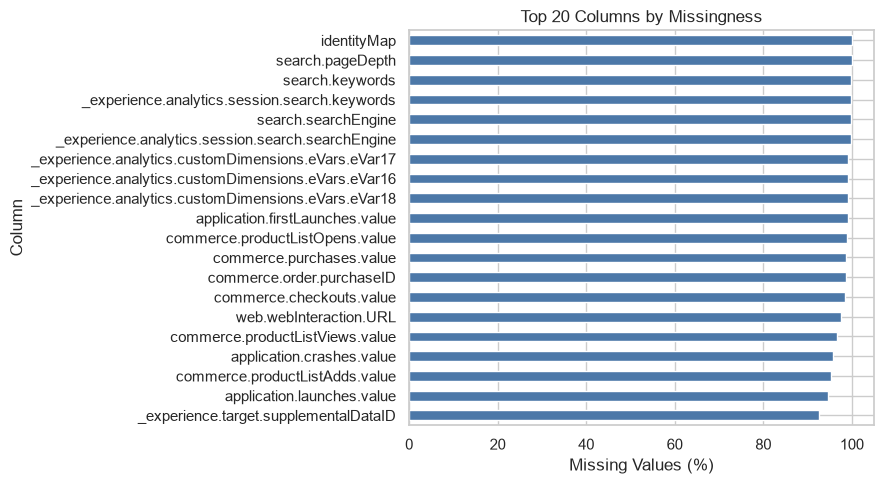

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
profile.head(20).sort_values('missing_pct').plot.barh(y='missing_pct', ax=ax, legend=False, color='#4c78a8')
ax.set_title('Top 20 Columns by Missingness')
ax.set_xlabel('Missing Values (%)')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

## 3. Cleaning and Feature Engineering

Cleaning decisions:

- Drop rows without a customer ID because they cannot be mapped to a customer journey.
- Convert timestamps and event count fields into usable numeric/date types.
- Treat missing event counters as zero because those fields are sparsely populated event indicators.
- Parse order value from `productListItems` where available.
- Aggregate event-level rows into one customer-level modeling table.
- For converted customers, use only events before the first purchase for model features to reduce target leakage.

In [6]:
def parse_revenue(product_text):
    """Extract numeric product prices from productListItems strings."""
    if pd.isna(product_text):
        return 0.0
    prices = re.findall(r',\s*([0-9]+(?:\.[0-9]+)?)\s*\)', str(product_text))
    return sum(float(price) for price in prices)


def mode_or_unknown(series):
    mode = series.dropna().astype(str).mode()
    return mode.iat[0] if not mode.empty else 'unknown'


def prepare_events(df):
    events = df.copy()
    events.columns = events.columns.str.strip()

    value_cols = [col for col in events.columns if col.endswith('.value')]
    value_cols += ['web.webPageDetails.pageViews.value', 'web.webInteraction.linkClicks.value']
    for col in set(value_cols):
        if col in events.columns:
            events[col] = pd.to_numeric(events[col], errors='coerce').fillna(0)

    events['timestamp'] = pd.to_datetime(events['timestamp'], errors='coerce')
    events = events.drop_duplicates()
    events = events.dropna(subset=['endUserIDs._experience.mcid.id']).copy()

    events['basket_revenue'] = events['productListItems'].apply(parse_revenue)
    events['is_purchase_event'] = (events['commerce.purchases.value'] > 0).astype(int)
    events['is_email'] = events['marketing.trackingCode'].fillna('').str.lower().eq('emaillaunch').astype(int)
    events['is_mobile_app'] = events['application.name'].notna().astype(int)
    return events


events = prepare_events(raw)
customer_id = 'endUserIDs._experience.mcid.id'

first_purchase = (
    events.loc[events['is_purchase_event'].eq(1)]
    .groupby(customer_id)['timestamp']
    .min()
    .rename('first_purchase_ts')
)

events = events.merge(first_purchase, on=customer_id, how='left')
events['converted_customer'] = events['first_purchase_ts'].notna().astype(int)
pre_purchase_events = events[
    events['first_purchase_ts'].isna() | (events['timestamp'] < events['first_purchase_ts'])
].copy()

print(f'Clean event rows: {len(events):,}')
print(f'Pre-purchase modeling event rows: {len(pre_purchase_events):,}')

Clean event rows: 46,108
Pre-purchase modeling event rows: 38,182


In [7]:
customer_features = pre_purchase_events.groupby(customer_id).agg(
    events=('_id', 'count'),
    first_event=('timestamp', 'min'),
    last_event=('timestamp', 'max'),
    sessions=('_experience.analytics.session.num', 'nunique'),
    max_session_depth=('_experience.analytics.session.depth', 'max'),
    mean_session_depth=('_experience.analytics.session.depth', 'mean'),
    page_views=('web.webPageDetails.pageViews.value', 'sum'),
    product_views=('commerce.productViews.value', 'sum'),
    product_list_views=('commerce.productListViews.value', 'sum'),
    cart_adds=('commerce.productListAdds.value', 'sum'),
    checkouts=('commerce.checkouts.value', 'sum'),
    link_clicks=('web.webInteraction.linkClicks.value', 'sum'),
    unique_pages=('web.webPageDetails.name', 'nunique'),
    unique_sections=('web.webPageDetails.siteSection', 'nunique'),
    email_touches=('is_email', 'sum'),
    mobile_app_events=('is_mobile_app', 'sum'),
    primary_referrer=('web.webReferrer.type', mode_or_unknown),
    country=('placeContext.geo.countryCode', mode_or_unknown),
    device_type=('device.typeID', mode_or_unknown),
).reset_index().rename(columns={customer_id: 'customer_id'})

targets = events.groupby(customer_id).agg(
    converted=('converted_customer', 'max'),
    purchase_events=('commerce.purchases.value', 'sum'),
    orders=('commerce.order.purchaseID', 'nunique'),
    revenue=('basket_revenue', 'sum'),
).reset_index().rename(columns={customer_id: 'customer_id'})

customers = customer_features.merge(targets, on='customer_id', how='right')

for col in customers.select_dtypes(include=np.number).columns:
    customers[col] = customers[col].fillna(0)
for col in ['primary_referrer', 'country', 'device_type']:
    customers[col] = customers[col].fillna('unknown').astype(str)

customers['journey_minutes'] = (
    pd.to_datetime(customers['last_event']) - pd.to_datetime(customers['first_event'])
).dt.total_seconds().div(60).fillna(0)
customers['avg_order_value'] = np.where(customers['orders'] > 0, customers['revenue'] / customers['orders'], 0)
customers['cart_add_rate'] = np.where(customers['product_views'] > 0, customers['cart_adds'] / customers['product_views'], 0)
customers['checkout_rate'] = np.where(customers['cart_adds'] > 0, customers['checkouts'] / customers['cart_adds'], 0)
customers['email_flag'] = (customers['email_touches'] > 0).astype(int)
customers['mobile_flag'] = (customers['mobile_app_events'] > 0).astype(int)

summary = pd.Series({
    'customers': len(customers),
    'converted_customers': int(customers['converted'].sum()),
    'conversion_rate': customers['converted'].mean(),
    'orders': int(customers['orders'].sum()),
    'parsed_revenue': customers['revenue'].sum(),
    'median_pre_purchase_events': customers['events'].median(),
    'median_pre_purchase_journey_minutes': customers['journey_minutes'].median(),
}).to_frame('value')
summary

,value
customers,929.000
converted_customers,224.000
conversion_rate,0.241
orders,317.000
parsed_revenue,"63,798.280"
median_pre_purchase_events,18.000
median_pre_purchase_journey_minutes,3.083


## 4. Exploratory Data Analysis

The EDA below compares converters and non-converters, looks for outliers in behavioral depth, and checks which touchpoints appear most related to purchase behavior.

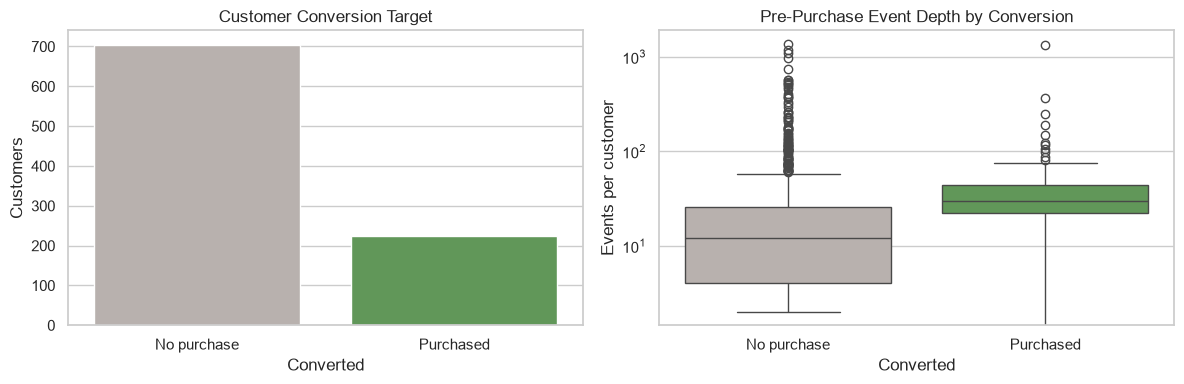

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=customers, x='converted', ax=axes[0], palette=['#bab0ac', '#59a14f'])
axes[0].set_title('Customer Conversion Target')
axes[0].set_xlabel('Converted')
axes[0].set_ylabel('Customers')
axes[0].set_xticklabels(['No purchase', 'Purchased'])

sns.boxplot(data=customers, x='converted', y='events', ax=axes[1], palette=['#bab0ac', '#59a14f'])
axes[1].set_title('Pre-Purchase Event Depth by Conversion')
axes[1].set_xlabel('Converted')
axes[1].set_ylabel('Events per customer')
axes[1].set_yscale('log')
axes[1].set_xticklabels(['No purchase', 'Purchased'])

plt.tight_layout()
plt.show()

In [9]:
behavior_cols = ['events', 'page_views', 'product_views', 'cart_adds', 'checkouts', 'unique_sections', 'journey_minutes']
behavior_summary = customers.groupby('converted')[behavior_cols].median().T
behavior_summary.columns = ['non_converter_median', 'converter_median']
behavior_summary['converter_lift'] = behavior_summary['converter_median'] / behavior_summary['non_converter_median'].replace(0, np.nan)
behavior_summary

,non_converter_median,converter_median,converter_lift
events,12.000,30.000,2.500
page_views,10.000,24.000,2.400
product_views,0.000,4.000,NaN
cart_adds,0.000,4.000,NaN
checkouts,0.000,2.000,NaN
unique_sections,2.000,8.500,4.250
journey_minutes,2.683,3.375,1.258


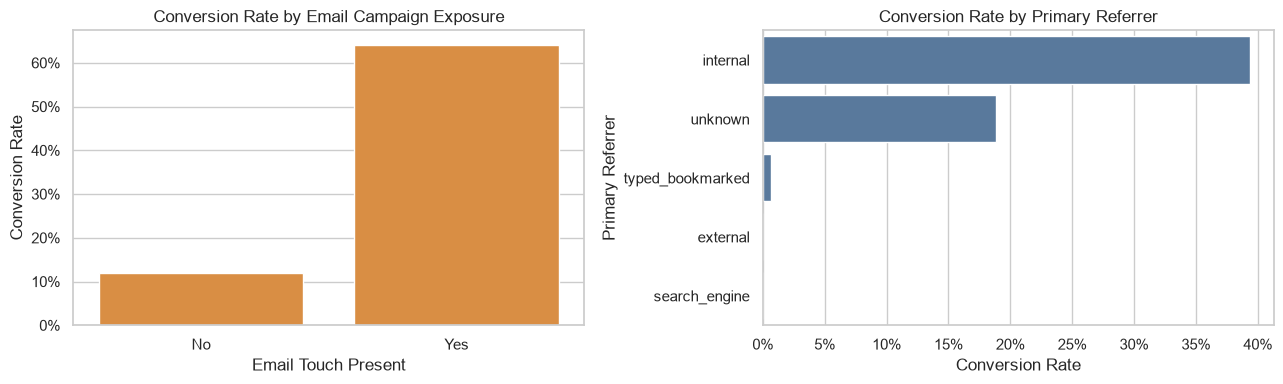

,primary_referrer,customers,conversion_rate
0,internal,450,0.393
1,unknown,244,0.189
2,typed_bookmarked,150,0.007
3,external,24,0.000
4,search_engine,60,0.000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

email_rates = customers.groupby('email_flag')['converted'].mean().reset_index()
sns.barplot(data=email_rates, x='email_flag', y='converted', ax=axes[0], color='#f28e2b')
axes[0].set_title('Conversion Rate by Email Campaign Exposure')
axes[0].set_xlabel('Email Touch Present')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(['No', 'Yes'])
axes[0].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')

referrer_rates = (
    customers.groupby('primary_referrer')
    .agg(customers=('customer_id', 'count'), conversion_rate=('converted', 'mean'))
    .query('customers >= 10')
    .sort_values('conversion_rate', ascending=False)
    .reset_index()
)
sns.barplot(data=referrer_rates, y='primary_referrer', x='conversion_rate', ax=axes[1], color='#4e79a7')
axes[1].set_title('Conversion Rate by Primary Referrer')
axes[1].set_xlabel('Conversion Rate')
axes[1].set_ylabel('Primary Referrer')
axes[1].xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')

plt.tight_layout()
plt.show()

referrer_rates

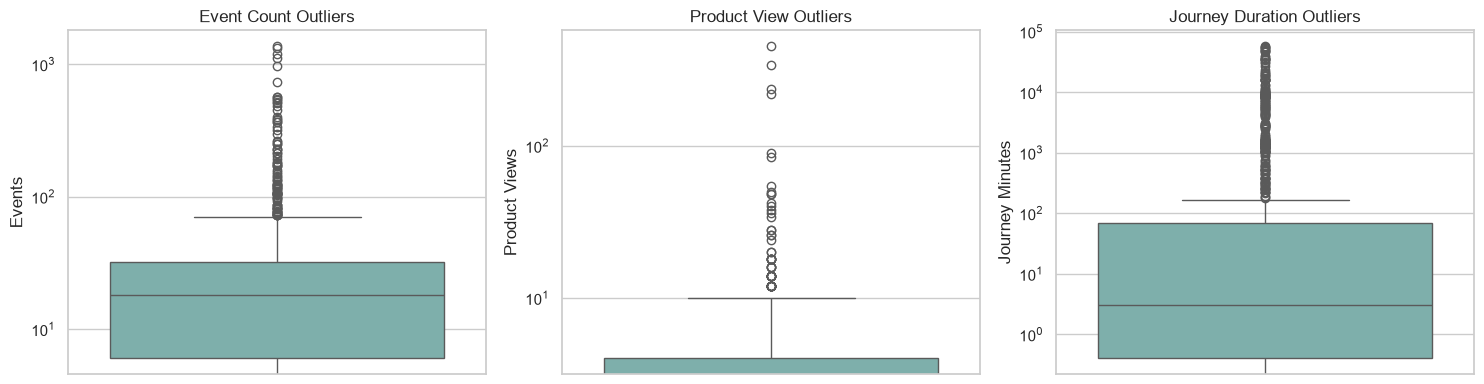

,count,mean,std,min,50%,75%,90%,95%,99%,max
events,929.000,41.100,110.137,0.000,18.000,32.000,70.400,128.800,526.960,"1,370.000"
product_views,929.000,4.164,22.281,0.000,0.000,4.000,8.000,12.000,46.320,452.000
cart_adds,929.000,1.552,3.870,0.000,0.000,2.000,4.000,6.000,14.000,48.000
checkouts,929.000,0.502,1.035,0.000,0.000,0.000,2.000,2.000,2.000,14.000
journey_minutes,929.000,"1,796.896","6,718.772",0.000,3.083,68.183,"4,038.773","9,156.573","39,762.456","57,573.983"


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ['events', 'product_views', 'journey_minutes'],
    ['Event Count Outliers', 'Product View Outliers', 'Journey Duration Outliers']
):
    sns.boxplot(data=customers, y=col, ax=ax, color='#76b7b2')
    ax.set_yscale('log')
    ax.set_title(title)
    ax.set_ylabel(col.replace('_', ' ').title())
plt.tight_layout()
plt.show()

customers[['events', 'product_views', 'cart_adds', 'checkouts', 'journey_minutes']].describe(percentiles=[.5, .75, .9, .95, .99]).T

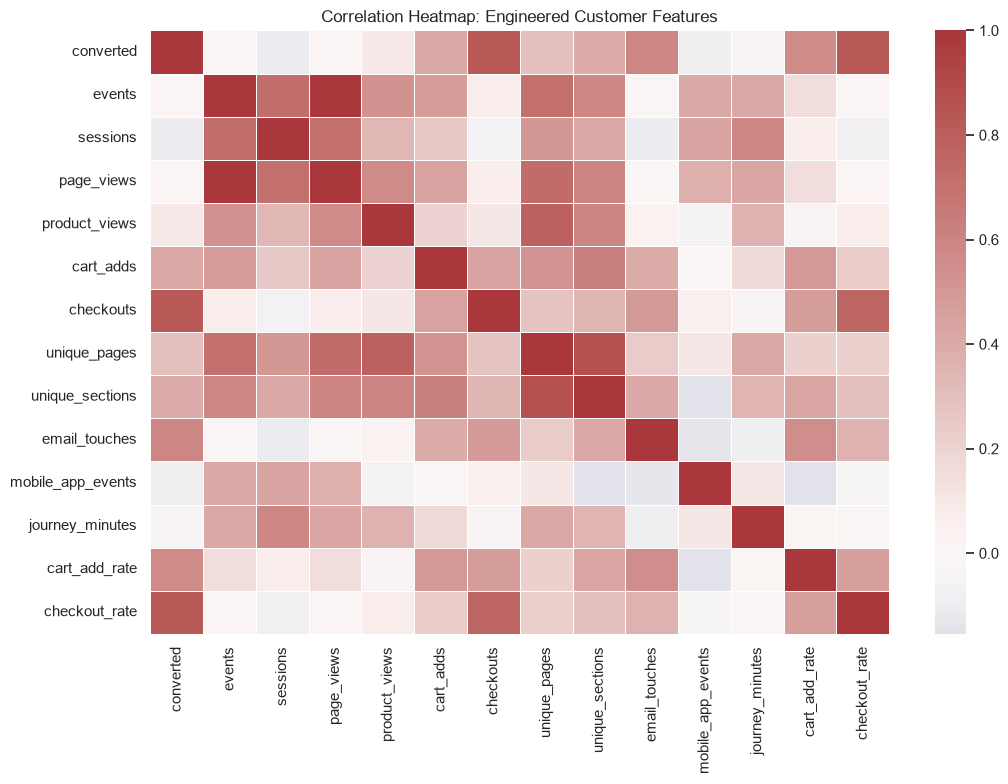

In [12]:
corr_cols = [
    'converted', 'events', 'sessions', 'page_views', 'product_views', 'cart_adds',
    'checkouts', 'unique_pages', 'unique_sections', 'email_touches', 'mobile_app_events',
    'journey_minutes', 'cart_add_rate', 'checkout_rate'
]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(customers[corr_cols].corr(), cmap='vlag', center=0, linewidths=.5, ax=ax)
ax.set_title('Correlation Heatmap: Engineered Customer Features')
plt.tight_layout()
plt.show()

## 5. Customer Segmentation

K-means clustering is used as an initial unsupervised learning approach. The goal is not to create final production segments, but to identify meaningful behavioral groups that can support engagement recommendations.

In [13]:
cluster_features = [
    'events', 'sessions', 'page_views', 'product_views', 'cart_adds',
    'checkouts', 'unique_sections', 'journey_minutes', 'email_touches', 'mobile_app_events'
]

cluster_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
Z = cluster_preprocess.fit_transform(customers[cluster_features])

silhouette_rows = []
for k in range(3, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(Z)
    silhouette_rows.append({'k': k, 'silhouette_score': silhouette_score(Z, labels)})

silhouette_df = pd.DataFrame(silhouette_rows)
silhouette_df

,k,silhouette_score
0,3,0.502
1,4,0.531
2,5,0.538
3,6,0.550


In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
customers['segment'] = kmeans.fit_predict(Z)

segment_summary = (
    customers.groupby('segment')
    .agg(
        customers=('customer_id', 'count'),
        conversion_rate=('converted', 'mean'),
        avg_events=('events', 'mean'),
        avg_product_views=('product_views', 'mean'),
        avg_cart_adds=('cart_adds', 'mean'),
        avg_checkouts=('checkouts', 'mean'),
        avg_revenue=('revenue', 'mean'),
        email_rate=('email_flag', 'mean'),
        mobile_rate=('mobile_flag', 'mean'),
    )
    .sort_values('conversion_rate', ascending=False)
)
segment_summary

,customers,conversion_rate,avg_events,avg_product_views,avg_cart_adds,avg_checkouts,avg_revenue,email_rate,mobile_rate
segment,,,,,,,,,
1,230,0.935,41.313,5.313,4.504,1.930,248.534,0.635,0.183
3,12,0.250,758.833,122.333,18.333,0.500,353.187,0.083,0.000
2,20,0.050,305.500,0.000,1.400,0.800,63.679,0.000,1.000
0,667,0.007,20.186,1.766,0.237,0.000,1.685,0.102,0.268


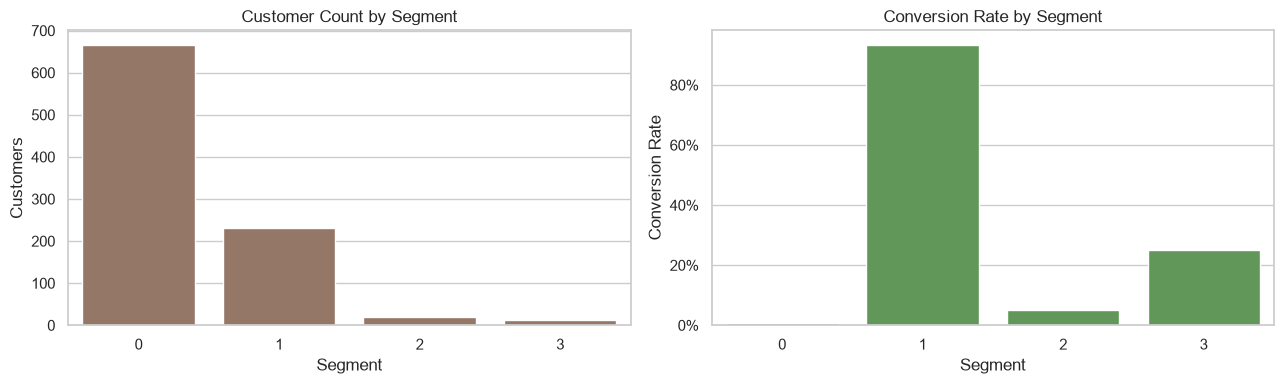

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_segments = segment_summary.reset_index()

sns.barplot(data=plot_segments, x='segment', y='customers', ax=axes[0], color='#9c755f')
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Customers')

sns.barplot(data=plot_segments, x='segment', y='conversion_rate', ax=axes[1], color='#59a14f')
axes[1].set_title('Conversion Rate by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Conversion Rate')
axes[1].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')

plt.tight_layout()
plt.show()

## 6. Baseline Purchase Propensity Model

A logistic regression classifier is used as the baseline because it is fast, interpretable, and appropriate for a binary purchase/no-purchase target. Because only about one quarter of customers converted, ROC-AUC, recall, precision, and F1 are more useful than accuracy alone.

The model uses pre-purchase customer behavior, but checkout and cart-add variables are still close to conversion. In the next phase, I would test stricter prediction windows such as predicting before cart or before checkout.

In [16]:
model_features = [
    'events', 'sessions', 'max_session_depth', 'mean_session_depth', 'page_views',
    'product_views', 'product_list_views', 'cart_adds', 'checkouts', 'link_clicks',
    'unique_pages', 'unique_sections', 'email_touches', 'mobile_app_events',
    'journey_minutes', 'cart_add_rate', 'checkout_rate', 'primary_referrer',
    'country', 'device_type'
]

target = 'converted'
X = customers[model_features].copy()
y = customers[target]

categorical_features = ['primary_referrer', 'country', 'device_type']
for col in categorical_features:
    X[col] = X[col].astype(str)

numeric_features = [col for col in model_features if col not in categorical_features]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

models = {
    'Dummy majority baseline': Pipeline([
        ('preprocess', preprocessor),
        ('model', DummyClassifier(strategy='most_frequent')),
    ]),
    'Logistic regression baseline': Pipeline([
        ('preprocess', preprocessor),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    ]),
}

metric_rows = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    metric_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions, zero_division=0),
        'recall': recall_score(y_test, predictions, zero_division=0),
        'f1': f1_score(y_test, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_test, probabilities),
    })

metrics = pd.DataFrame(metric_rows).set_index('model')
metrics

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy majority baseline,0.760,0.000,0.000,0.000,0.500
Logistic regression baseline,0.996,1.000,0.982,0.991,0.994


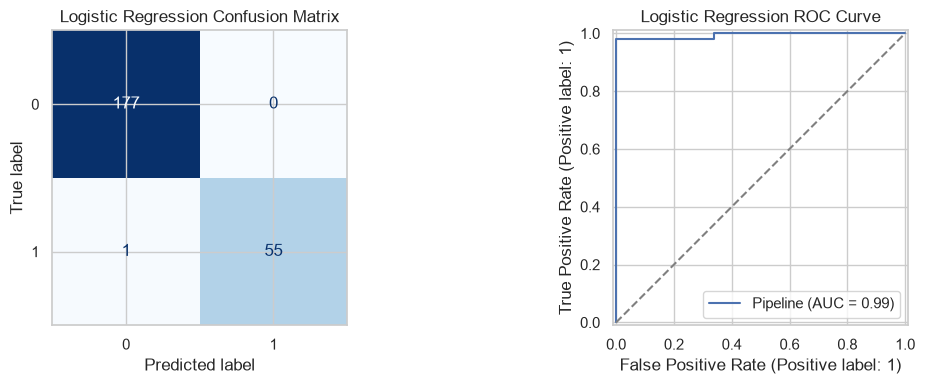

In [17]:
logit_model = fitted_models['Logistic regression baseline']
logit_predictions = logit_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, logit_predictions, ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')

RocCurveDisplay.from_estimator(logit_model, X_test, y_test, ax=axes[1])
axes[1].set_title('Logistic Regression ROC Curve')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.tight_layout()
plt.show()

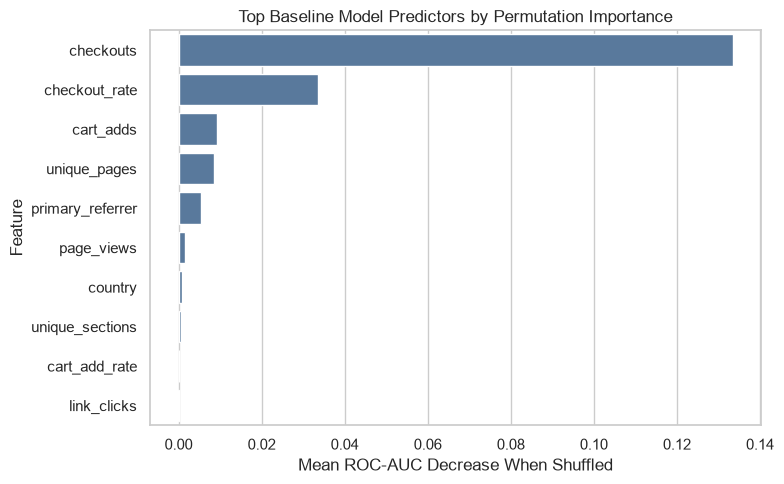

,feature,importance
8,checkouts,0.133
16,checkout_rate,0.034
7,cart_adds,0.009
10,unique_pages,0.009
17,primary_referrer,0.005
4,page_views,0.001
18,country,0.001
11,unique_sections,0.000
15,cart_add_rate,0.000
9,link_clicks,-0.000


In [18]:
importance = permutation_importance(
    logit_model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=20,
    random_state=42,
    n_jobs=1,
)

importance_df = (
    pd.DataFrame({'feature': model_features, 'importance': importance.importances_mean})
    .sort_values('importance', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df.head(10), y='feature', x='importance', ax=ax, color='#4e79a7')
ax.set_title('Top Baseline Model Predictors by Permutation Importance')
ax.set_xlabel('Mean ROC-AUC Decrease When Shuffled')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df.head(12)

## 7. Next-Best-Action Decisioning Prototype

The final project will refine this logic, but a simple rule-based prototype can already connect model outputs and customer segments to engagement recommendations.

In [19]:
customers['purchase_propensity'] = logit_model.predict_proba(X)[:, 1]

high_conversion_segment = segment_summary.index[0]
low_conversion_segment = segment_summary.index[-1]

def recommend_action(row):
    if row['purchase_propensity'] >= 0.70 and row['checkouts'] > 0:
        return 'Recover checkout: reminder, incentive, or abandoned-cart message'
    if row['purchase_propensity'] >= 0.70:
        return 'High intent: personalize product recommendations and urgency message'
    if row['email_flag'] == 1 and row['purchase_propensity'] >= 0.40:
        return 'Nurture email responder: send tailored offer or product bundle'
    if row['segment'] == low_conversion_segment:
        return 'Low intent: awareness content and softer re-engagement'
    return 'Continue browsing nurture and collect more behavioral signals'

customers['next_best_action'] = customers.apply(recommend_action, axis=1)

action_summary = (
    customers.groupby('next_best_action')
    .agg(
        customers=('customer_id', 'count'),
        avg_propensity=('purchase_propensity', 'mean'),
        actual_conversion_rate=('converted', 'mean'),
        avg_revenue=('revenue', 'mean'),
    )
    .sort_values('avg_propensity', ascending=False)
)

action_summary

,customers,avg_propensity,actual_conversion_rate,avg_revenue
next_best_action,,,,
"Recover checkout: reminder, incentive, or abandoned-cart message",219,0.987,0.995,280.370
Continue browsing nurture and collect more behavioral signals,43,0.029,0.023,29.618
Low intent: awareness content and softer re-engagement,667,0.026,0.007,1.685


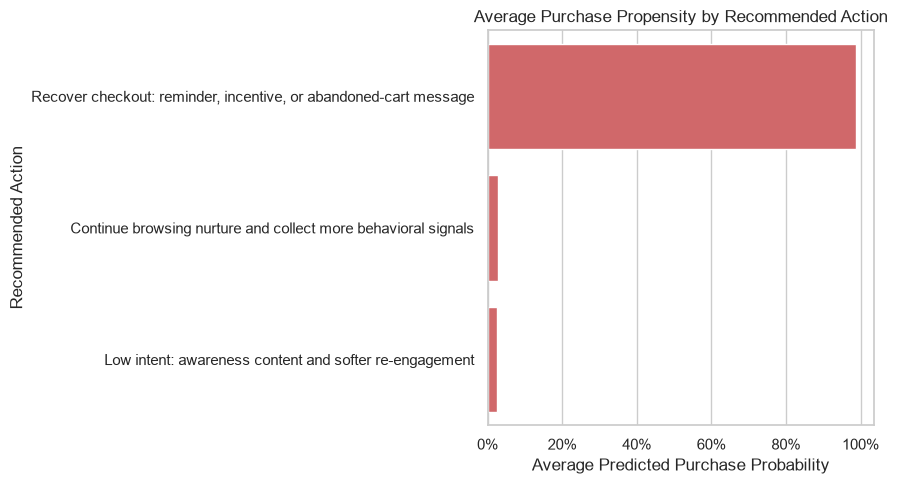

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
action_plot = action_summary.reset_index()
sns.barplot(data=action_plot, y='next_best_action', x='avg_propensity', ax=ax, color='#e15759')
ax.set_title('Average Purchase Propensity by Recommended Action')
ax.set_xlabel('Average Predicted Purchase Probability')
ax.set_ylabel('Recommended Action')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.tight_layout()
plt.show()

## 8. Initial Findings

- The cleaned dataset contains **929 customers** and **46,108 usable events**.
- **224 customers converted**, for a customer-level conversion rate of about **24.1%**.
- Customers with an email campaign touch converted at about **64.2%**, compared with **12.0%** for customers without an email touch.
- Internal navigation/referral paths were much more associated with conversion than typed/bookmarked, search, external, or social referrers.
- The baseline logistic regression strongly outperformed the majority-class dummy baseline. The most important predictors were checkout activity, checkout rate, cart adds, unique pages, and primary referrer.
- The clustering analysis identified one large low-conversion segment and one high-intent segment with high checkout/cart activity and high revenue.

### Modeling caveat

The baseline is intentionally simple and useful for comparison in the next module, but its performance is likely optimistic because checkout and cart-add features are very close to the purchase event. The next modeling iteration should evaluate earlier prediction windows, compare tree-based models, tune thresholds based on business cost, and validate the next-best-action rules with holdout or experiment data.